In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

print(DATA_ROOT)
print("Existe?", DATA_ROOT.exists())

/content/drive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado
Existe? True


In [ ]:
flights = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])

print("Quantidade de voos encontrados:", len(flights))
print("\nPrimeiros 20 voos:")
for f in flights[:20]:
    print(f)

Quantidade de voos encontrados: 49

Primeiros 20 voos:
_reports
carbonZ_2018-07-18-12-10-11_no_ground_truth
carbonZ_2018-07-18-15-53-31_1_engine_failure
carbonZ_2018-07-18-15-53-31_2_engine_failure
carbonZ_2018-07-18-16-22-01_engine_failure_with_emr_traj
carbonZ_2018-07-18-16-37-39_1_no_failure
carbonZ_2018-07-18-16-37-39_2_engine_failure_with_emr_traj
carbonZ_2018-07-30-16-29-45_engine_failure_with_emr_traj
carbonZ_2018-07-30-16-39-00_1_engine_failure
carbonZ_2018-07-30-16-39-00_2_engine_failure
carbonZ_2018-07-30-16-39-00_3_no_failure
carbonZ_2018-07-30-16-39-00_3_no_failure_synthetic_attack_v1
carbonZ_2018-07-30-17-10-45_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-20-01_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-36-35_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-46-31_engine_failure_with_emr_traj
carbonZ_2018-09-11-11-56-30_engine_failure
carbonZ_2018-09-11-14-16-55_no_failure
carbonZ_2018-09-11-14-22-07_1_engine_failure
carbonZ_2018-09-11-14-22-07_2_engine_fail

In [ ]:
nominal_flights = [f for f in flights if "no_failure" in f.lower()]

print("Quantidade de voos nominais:", len(nominal_flights))
print("\nPrimeiros 20 voos nominais:")
for f in nominal_flights[:20]:
    print(f)

Quantidade de voos nominais: 11

Primeiros 20 voos nominais:
carbonZ_2018-07-18-16-37-39_1_no_failure
carbonZ_2018-07-30-16-39-00_3_no_failure
carbonZ_2018-07-30-16-39-00_3_no_failure_synthetic_attack_v1
carbonZ_2018-09-11-14-16-55_no_failure
carbonZ_2018-09-11-14-41-38_no_failure
carbonZ_2018-09-11-15-05-11_2_no_failure
carbonZ_2018-10-05-14-34-20_1_no_failure
carbonZ_2018-10-05-14-37-22_1_no_failure
carbonZ_2018-10-05-15-52-12_1_no_failure
carbonZ_2018-10-05-15-52-12_2_no_failure
carbonZ_2018-10-18-11-08-24_no_failure


In [ ]:
flight_name = "carbonZ_2018-07-30-16-39-00_3_no_failure"
print("Voo escolhido:", flight_name)

Voo escolhido: carbonZ_2018-07-30-16-39-00_3_no_failure


In [ ]:
csv_path = DATA_ROOT / flight_name / "flight_consolidated.csv"

print(csv_path)
print("Arquivo existe?", csv_path.exists())

df_original = pd.read_csv(csv_path).copy()

print("Shape:", df_original.shape)
print("\nColunas:")
print(df_original.columns.tolist())

/content/drive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/carbonZ_2018-07-30-16-39-00_3_no_failure/flight_consolidated.csv
Arquivo existe? True
Shape: (324, 12)

Colunas:
['time_s', 'x_m', 'y_m', 'z_m', 'vx_mps', 'vy_mps', 'vz_mps', 'voltage_v', 'current_a', 'battery_pct', 'speed_mps', 'power_w']


In [ ]:
required_cols = ["time_s", "vx_mps", "vy_mps"]

df_original = df_original.replace([np.inf, -np.inf], np.nan)
df_original = df_original.dropna(subset=required_cols).copy()
df_original = df_original.sort_values("time_s").reset_index(drop=True)

print("Shape após limpeza:", df_original.shape)

Shape após limpeza: (324, 12)


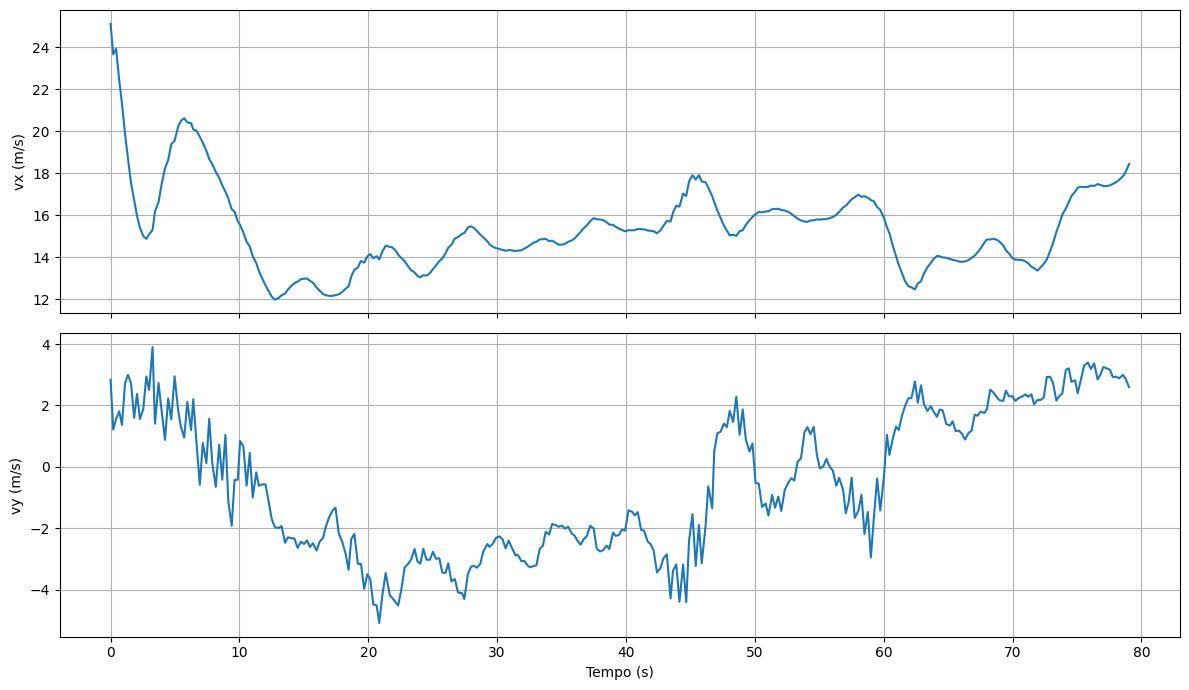

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax[0].plot(df_original["time_s"], df_original["vx_mps"])
ax[0].set_ylabel("vx (m/s)")
ax[0].grid(True)

ax[1].plot(df_original["time_s"], df_original["vy_mps"])
ax[1].set_xlabel("Tempo (s)")
ax[1].set_ylabel("vy (m/s)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
attack_windows = [
    (40, 55),
    (60, 75)
]

print("Janelas de ataque:")
for i, (start_attack, end_attack) in enumerate(attack_windows, start=1):
    print(f"Janela {i}: {start_attack} até {end_attack}")

Janelas de ataque:
Janela 1: 40 até 55
Janela 2: 60 até 75


In [ ]:
def inject_sine_attack(df, attack_windows, amp_vx=4.0, amp_vy=2.5):

    df_attacked = df.copy()
    df_attacked["synthetic_attack"] = 0

    t = df_attacked["time_s"].to_numpy()

    for start_time, end_time in attack_windows:
        mask = (t >= start_time) & (t <= end_time)
        idx = np.where(mask)[0]

        if len(idx) == 0:
            continue

        phase = np.linspace(0, np.pi, len(idx))

        df_attacked.loc[idx, "vx_mps"] += amp_vx * np.sin(phase)
        df_attacked.loc[idx, "vy_mps"] += amp_vy * np.sin(phase)

        df_attacked.loc[idx, "synthetic_attack"] = 1

    return df_attacked

In [ ]:
def inject_drift_attack(df, attack_windows, drift_vx=0.35, drift_vy=0.2):

    df_attacked = df.copy()
    df_attacked["synthetic_attack"] = 0

    t = df_attacked["time_s"].to_numpy()

    for start_time, end_time in attack_windows:
        mask = (t >= start_time) & (t <= end_time)
        idx = np.where(mask)[0]

        if len(idx) == 0:
            continue

        local_t = t[idx]
        t0 = local_t[0]

        df_attacked.loc[idx, "vx_mps"] += drift_vx * (local_t - t0)
        df_attacked.loc[idx, "vy_mps"] += drift_vy * (local_t - t0)

        df_attacked.loc[idx, "synthetic_attack"] = 1

    return df_attacked

In [ ]:
df_sine = inject_sine_attack(df_original, attack_windows)
df_drift = inject_drift_attack(df_original, attack_windows)

print("Senoidal:", df_sine["synthetic_attack"].sum())
print("Drift:", df_drift["synthetic_attack"].sum())

Senoidal: 122
Drift: 122


In [ ]:
def plot_confusion_matrix(tp, tn, fp, fn, title="Matriz de Confusão"):
    cm = np.array([
        [tn, fp],
        [fn, tp]
    ])

    labels_x = ["Predito: Não ataque", "Predito: Ataque"]
    labels_y = ["Real: Não ataque", "Real: Ataque"]

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="YlGnBu")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels_x)
    ax.set_yticklabels(labels_y)

    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                fontsize=14, fontweight="bold", color=color
            )

    ax.set_title(title)
    ax.set_xlabel("Classe Predita")
    ax.set_ylabel("Classe Real")

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Número de amostras", rotation=90)

    plt.tight_layout()
    plt.show()

In [ ]:
def run_jerk_detector(
    df_attacked,
    df_baseline,
    attack_windows,
    window=0.5,
    make_plots=True,
    detector_name="Detector por jerk"
):
    df_base = df_baseline.copy()
    df = df_attacked.copy()

    # -----------------------------
    # baseline para o limiar
    # -----------------------------
    df_base["v_mps"] = np.sqrt(df_base["vx_mps"]**2 + df_base["vy_mps"]**2)
    df_base["dt"] = df_base["time_s"].diff()
    df_base["acc_mps2"] = df_base["v_mps"].diff() / df_base["dt"]

    df_base = df_base.replace([np.inf, -np.inf], np.nan)
    df_base = df_base.dropna(subset=["acc_mps2"]).copy()

    df_base["jerk_mps3"] = df_base["acc_mps2"].diff() / df_base["dt"]
    df_base = df_base.replace([np.inf, -np.inf], np.nan)
    df_base = df_base.dropna(subset=["jerk_mps3"]).copy()

    median_jerk = df_base["jerk_mps3"].median()
    mad_jerk = np.median(np.abs(df_base["jerk_mps3"] - median_jerk))
    threshold_jerk = median_jerk + 3 * mad_jerk

    # -----------------------------
    # dados atacados para detecção
    # -----------------------------
    df["v_mps"] = np.sqrt(df["vx_mps"]**2 + df["vy_mps"]**2)
    df["dt"] = df["time_s"].diff()
    df["acc_mps2"] = df["v_mps"].diff() / df["dt"]

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["acc_mps2"]).copy()

    df["jerk_mps3"] = df["acc_mps2"].diff() / df["dt"]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["jerk_mps3"]).copy()

    df["anomaly_jerk"] = (np.abs(df["jerk_mps3"]) > threshold_jerk).astype(int)

    if make_plots:
        plt.figure(figsize=(12, 4))
        plt.plot(df["time_s"], df["jerk_mps3"], label="Jerk")
        plt.axhline(threshold_jerk, linestyle="--", label="Limiar")
        plt.axhline(-threshold_jerk, linestyle="--")

        for i, (start_attack, end_attack) in enumerate(attack_windows):
            if i == 0:
                plt.axvspan(start_attack, end_attack, color="red", alpha=0.15, label="Janelas do ataque")
            else:
                plt.axvspan(start_attack, end_attack, color="red", alpha=0.15)

        plt.xlabel("Tempo (s)")
        plt.ylabel("Jerk (m/s³)")
        plt.title(detector_name)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    df["predicted_attack_jerk"] = 0

    for t in df.loc[df["anomaly_jerk"] == 1, "time_s"]:
        mask = (
            (df["time_s"] >= t - window) &
            (df["time_s"] <= t + window)
        )
        df.loc[mask, "predicted_attack_jerk"] = 1

    df_eval = df.copy()
    df_eval["ground_truth_attack"] = df_eval["synthetic_attack"].astype(int)
    df_eval["predicted_attack"] = df_eval["predicted_attack_jerk"].astype(int)

    y_true = df_eval["ground_truth_attack"].to_numpy()
    y_pred = df_eval["predicted_attack"].to_numpy()

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return df, df_eval, {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "threshold_jerk": threshold_jerk
    }

In [ ]:
def run_physical_detector(
    df_attacked,
    df_baseline,
    attack_windows,
    phys_percentile=80,
    max_gap_phys=1.0,
    min_duration_phys=0.2,
    make_plots=True,
    detector_name="Detector físico"
):
    df_base = df_baseline.copy()
    df_phys = df_attacked.copy()

    required_cols = ["time_s", "x_m", "y_m", "z_m", "vx_mps", "vy_mps", "vz_mps"]

    missing_base = [c for c in required_cols if c not in df_base.columns]
    missing_att = [c for c in required_cols if c not in df_phys.columns]

    if missing_base:
        raise ValueError(f"Faltam colunas no baseline para o detector físico: {missing_base}")
    if missing_att:
        raise ValueError(f"Faltam colunas no ataque para o detector físico: {missing_att}")

    # -----------------------------
    # baseline limpo para o limiar
    # -----------------------------
    df_base["v_measured_mps"] = np.sqrt(
        df_base["vx_mps"]**2 +
        df_base["vy_mps"]**2 +
        df_base["vz_mps"]**2
    )

    df_base["dx"] = df_base["x_m"].diff()
    df_base["dy"] = df_base["y_m"].diff()
    df_base["dz"] = df_base["z_m"].diff()
    df_base["dt_local"] = df_base["time_s"].diff()

    disp_base = np.sqrt(
        df_base["dx"]**2 +
        df_base["dy"]**2 +
        df_base["dz"]**2
    )

    df_base["v_from_disp_mps"] = disp_base / df_base["dt_local"]
    df_base["v_from_disp_mps"] = (
        df_base["v_from_disp_mps"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    df_base["phys_inconsistency"] = np.abs(
        df_base["v_measured_mps"] - df_base["v_from_disp_mps"]
    )

    threshold_phys = np.nanpercentile(
        df_base["phys_inconsistency"].to_numpy(dtype=float),
        phys_percentile
    )

    # -----------------------------
    # dados atacados para detecção
    # -----------------------------
    df_phys["v_measured_mps"] = np.sqrt(
        df_phys["vx_mps"]**2 +
        df_phys["vy_mps"]**2 +
        df_phys["vz_mps"]**2
    )

    df_phys["dx"] = df_phys["x_m"].diff()
    df_phys["dy"] = df_phys["y_m"].diff()
    df_phys["dz"] = df_phys["z_m"].diff()
    df_phys["dt_local"] = df_phys["time_s"].diff()

    disp_local = np.sqrt(
        df_phys["dx"]**2 +
        df_phys["dy"]**2 +
        df_phys["dz"]**2
    )

    df_phys["v_from_disp_mps"] = disp_local / df_phys["dt_local"]
    df_phys["v_from_disp_mps"] = (
        df_phys["v_from_disp_mps"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    df_phys["phys_inconsistency"] = np.abs(
        df_phys["v_measured_mps"] - df_phys["v_from_disp_mps"]
    )

    df_phys["anomaly_phys"] = (
        df_phys["phys_inconsistency"] > threshold_phys
    ).astype(int)

    if make_plots:
        plt.figure(figsize=(12, 4))
        plt.plot(df_phys["time_s"], df_phys["phys_inconsistency"], label="Inconsistência física")
        plt.axhline(threshold_phys, linestyle="--", label="Threshold físico")

        for i, (start_attack, end_attack) in enumerate(attack_windows):
            if i == 0:
                plt.axvspan(start_attack, end_attack, color="red", alpha=0.15, label="Janelas do ataque")
            else:
                plt.axvspan(start_attack, end_attack, color="red", alpha=0.15)

        plt.xlabel("Tempo (s)")
        plt.ylabel("Inconsistência (m/s)")
        plt.title(detector_name)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    anom_times = df_phys.loc[df_phys["anomaly_phys"] == 1, "time_s"].to_numpy()

    candidate_events = []

    if len(anom_times) > 0:
        start_evt = anom_times[0]
        prev_t = anom_times[0]

        for t in anom_times[1:]:
            if (t - prev_t) <= max_gap_phys:
                prev_t = t
            else:
                candidate_events.append((start_evt, prev_t))
                start_evt = t
                prev_t = t

        candidate_events.append((start_evt, prev_t))

    filtered_events = [
        (s, e) for s, e in candidate_events if (e - s) >= min_duration_phys
    ]

    df_phys["predicted_attack_phys"] = 0
    for s, e in filtered_events:
        mask_evt = (df_phys["time_s"] >= s) & (df_phys["time_s"] <= e)
        df_phys.loc[mask_evt, "predicted_attack_phys"] = 1

    df_eval = df_phys.copy()
    df_eval["ground_truth_attack"] = df_eval["synthetic_attack"].astype(int)
    df_eval["predicted_attack"] = df_eval["predicted_attack_phys"].astype(int)

    y_true = df_eval["ground_truth_attack"].to_numpy()
    y_pred = df_eval["predicted_attack"].to_numpy()

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return df_phys, df_eval, {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "threshold_phys": threshold_phys
    }

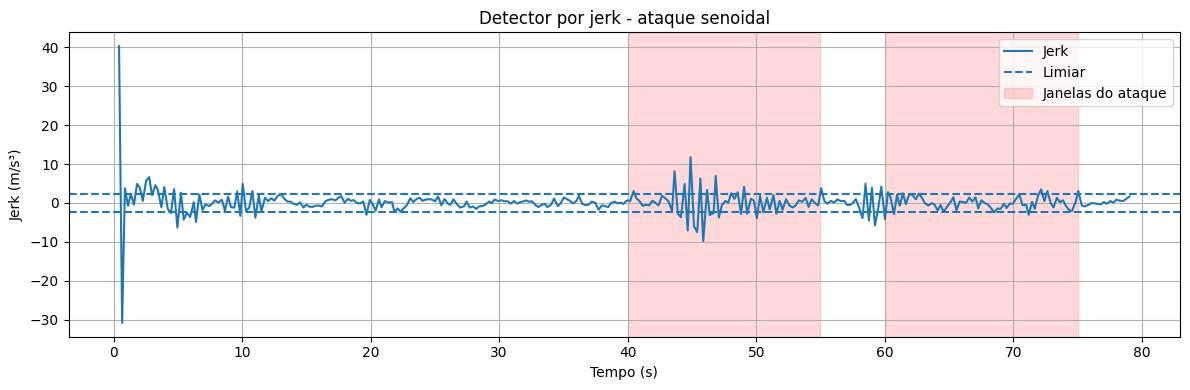

{'tp': 73, 'tn': 140, 'fp': 60, 'fn': 49, 'precision': 0.5488721804511278, 'recall': 0.5983606557377049, 'threshold_jerk': np.float64(2.3162628793397864)}


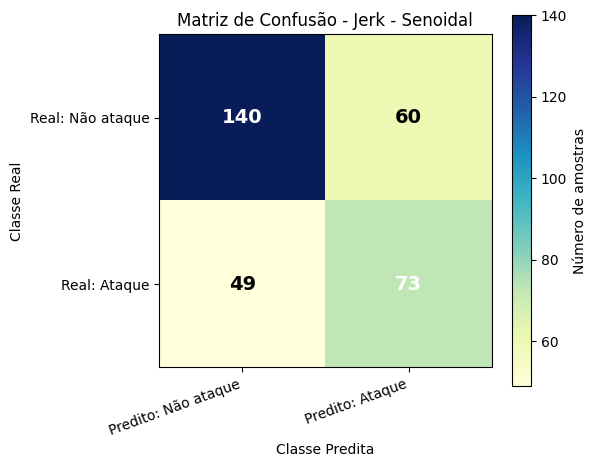

In [ ]:
df_jerk_sine, df_eval_jerk_sine, result_jerk_sine = run_jerk_detector(
    df_attacked=df_sine,
    df_baseline=df_original,
    attack_windows=attack_windows,
    window=0.5,
    make_plots=True,
    detector_name="Detector por jerk - ataque senoidal"
)

print(result_jerk_sine)

plot_confusion_matrix(
    result_jerk_sine["tp"],
    result_jerk_sine["tn"],
    result_jerk_sine["fp"],
    result_jerk_sine["fn"],
    title="Matriz de Confusão - Jerk - Senoidal"
)

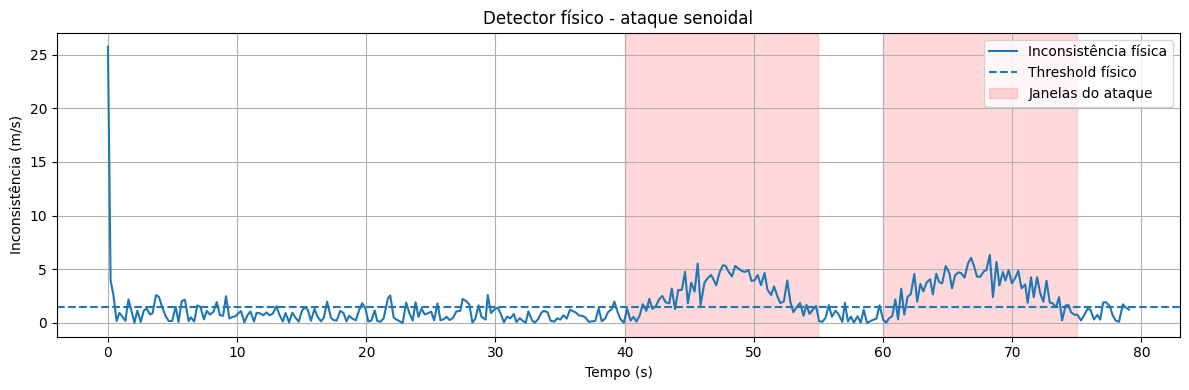

{'tp': 106, 'tn': 185, 'fp': 17, 'fn': 16, 'precision': 0.8617886178861789, 'recall': 0.8688524590163934, 'threshold_phys': np.float64(1.4772085184510424)}


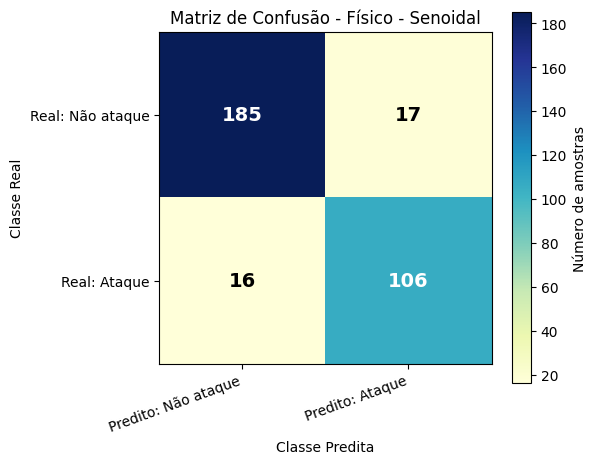

In [ ]:
df_phys_sine, df_eval_phys_sine, result_phys_sine = run_physical_detector(
    df_attacked=df_sine,
    df_baseline=df_original,
    attack_windows=attack_windows,
    phys_percentile=85,
    max_gap_phys=0.6,
    min_duration_phys=0.2,
    make_plots=True,
    detector_name="Detector físico - ataque senoidal"
)

print(result_phys_sine)

plot_confusion_matrix(
    result_phys_sine["tp"],
    result_phys_sine["tn"],
    result_phys_sine["fp"],
    result_phys_sine["fn"],
    title="Matriz de Confusão - Físico - Senoidal"
)

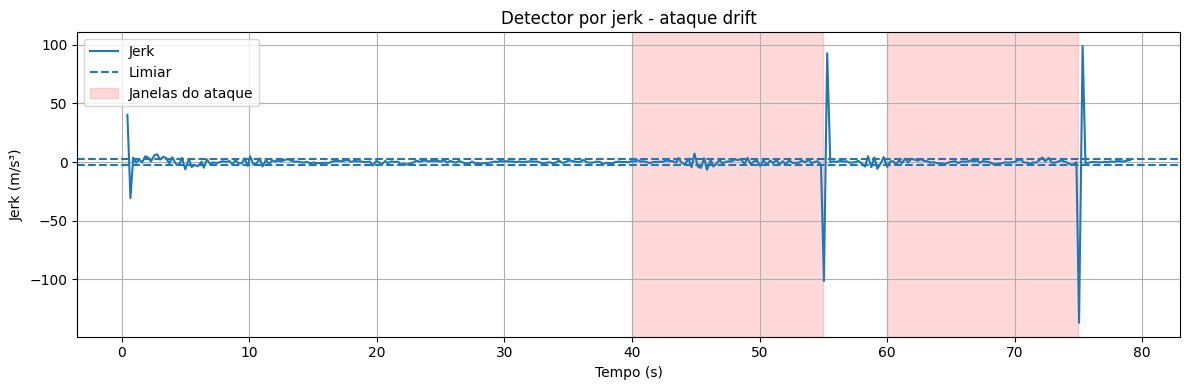

{'tp': 57, 'tn': 139, 'fp': 61, 'fn': 65, 'precision': 0.4830508474576271, 'recall': 0.4672131147540984, 'threshold_jerk': np.float64(2.3162628793397864)}


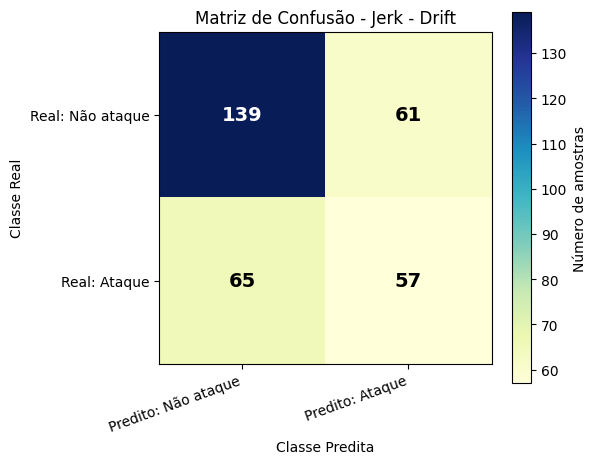

In [ ]:
df_jerk_drift, df_eval_jerk_drift, result_jerk_drift = run_jerk_detector(
    df_attacked=df_drift,
    df_baseline=df_original,
    attack_windows=attack_windows,
    window=0.5,
    make_plots=True,
    detector_name="Detector por jerk - ataque drift"
)

print(result_jerk_drift)

plot_confusion_matrix(
    result_jerk_drift["tp"],
    result_jerk_drift["tn"],
    result_jerk_drift["fp"],
    result_jerk_drift["fn"],
    title="Matriz de Confusão - Jerk - Drift"
)

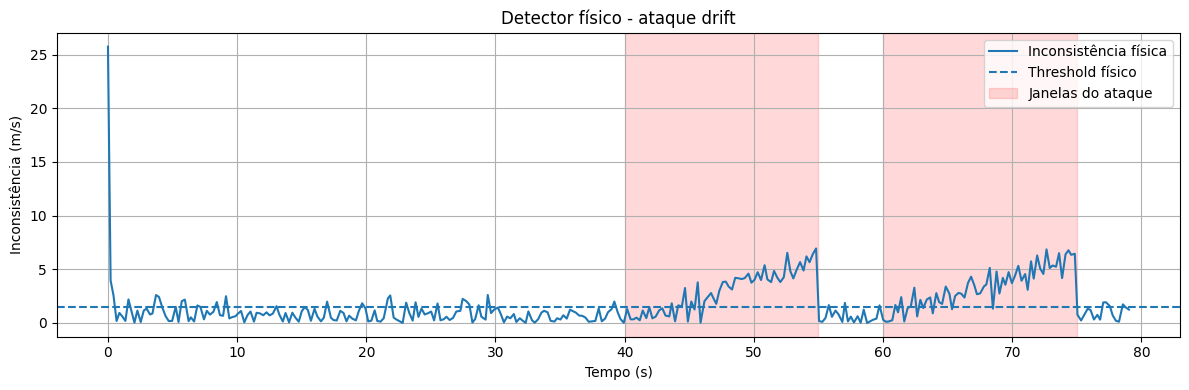

{'tp': 102, 'tn': 185, 'fp': 17, 'fn': 20, 'precision': 0.8571428571428571, 'recall': 0.8360655737704918, 'threshold_phys': np.float64(1.4772085184510424)}


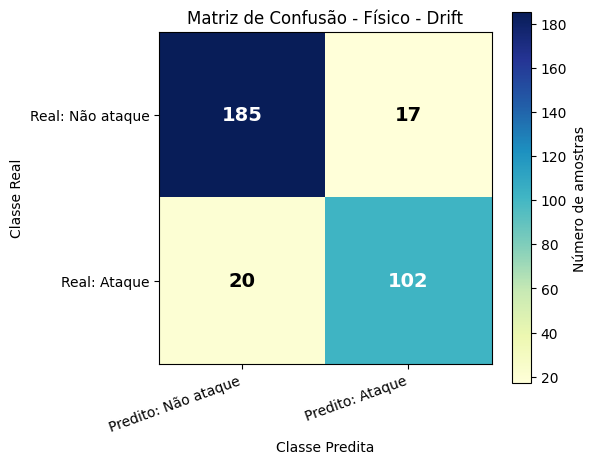

In [ ]:
df_phys_drift, df_eval_phys_drift, result_phys_drift = run_physical_detector(
    df_attacked=df_drift,
    df_baseline=df_original,
    attack_windows=attack_windows,
    phys_percentile=85,
    max_gap_phys=0.6,
    min_duration_phys=0.2,
    make_plots=True,
    detector_name="Detector físico - ataque drift"
)

print(result_phys_drift)

plot_confusion_matrix(
    result_phys_drift["tp"],
    result_phys_drift["tn"],
    result_phys_drift["fp"],
    result_phys_drift["fn"],
    title="Matriz de Confusão - Físico - Drift"
)

In [ ]:
summary_df = pd.DataFrame([
    {
        "Ataque": "Senoidal",
        "Detector": "Jerk",
        "TP": result_jerk_sine["tp"],
        "TN": result_jerk_sine["tn"],
        "FP": result_jerk_sine["fp"],
        "FN": result_jerk_sine["fn"],
        "Recall": result_jerk_sine["recall"],
        "Precisão": result_jerk_sine["precision"]
    },
    {
        "Ataque": "Senoidal",
        "Detector": "Físico",
        "TP": result_phys_sine["tp"],
        "TN": result_phys_sine["tn"],
        "FP": result_phys_sine["fp"],
        "FN": result_phys_sine["fn"],
        "Recall": result_phys_sine["recall"],
        "Precisão": result_phys_sine["precision"]
    },
    {
        "Ataque": "Drift",
        "Detector": "Jerk",
        "TP": result_jerk_drift["tp"],
        "TN": result_jerk_drift["tn"],
        "FP": result_jerk_drift["fp"],
        "FN": result_jerk_drift["fn"],
        "Recall": result_jerk_drift["recall"],
        "Precisão": result_jerk_drift["precision"]
    },
    {
        "Ataque": "Drift",
        "Detector": "Físico",
        "TP": result_phys_drift["tp"],
        "TN": result_phys_drift["tn"],
        "FP": result_phys_drift["fp"],
        "FN": result_phys_drift["fn"],
        "Recall": result_phys_drift["recall"],
        "Precisão": result_phys_drift["precision"]
    }
])

print("Resumo comparativo")
print("------------------")
summary_df

Resumo comparativo
------------------


,Ataque,Detector,TP,TN,FP,FN,Recall,Precisão
0,Senoidal,Jerk,73,140,60,49,0.598361,0.548872
1,Senoidal,Físico,106,185,17,16,0.868852,0.861789
2,Drift,Jerk,57,139,61,65,0.467213,0.483051
3,Drift,Físico,102,185,17,20,0.836066,0.857143


In [ ]:
print("Resumo comparativo")
print("------------------")

print(
    f"Senoidal - Jerk   -> TP={result_jerk_sine['tp']}, "
    f"TN={result_jerk_sine['tn']}, FP={result_jerk_sine['fp']}, FN={result_jerk_sine['fn']}, "
    f"Recall={result_jerk_sine['recall']:.4f}, Precisão={result_jerk_sine['precision']:.4f}"
)

print(
    f"Senoidal - Físico-> TP={result_phys_sine['tp']}, "
    f"TN={result_phys_sine['tn']}, FP={result_phys_sine['fp']}, FN={result_phys_sine['fn']}, "
    f"Recall={result_phys_sine['recall']:.4f}, Precisão={result_phys_sine['precision']:.4f}"
)

print(
    f"Drift    - Jerk   -> TP={result_jerk_drift['tp']}, "
    f"TN={result_jerk_drift['tn']}, FP={result_jerk_drift['fp']}, FN={result_jerk_drift['fn']}, "
    f"Recall={result_jerk_drift['recall']:.4f}, Precisão={result_jerk_drift['precision']:.4f}"
)

print(
    f"Drift    - Físico-> TP={result_phys_drift['tp']}, "
    f"TN={result_phys_drift['tn']}, FP={result_phys_drift['fp']}, FN={result_phys_drift['fn']}, "
    f"Recall={result_phys_drift['recall']:.4f}, Precisão={result_phys_drift['precision']:.4f}"
)

Resumo comparativo
------------------
Senoidal - Jerk   -> TP=73, TN=140, FP=60, FN=49, Recall=0.5984, Precisão=0.5489
Senoidal - Físico-> TP=106, TN=185, FP=17, FN=16, Recall=0.8689, Precisão=0.8618
Drift    - Jerk   -> TP=57, TN=139, FP=61, FN=65, Recall=0.4672, Precisão=0.4831
Drift    - Físico-> TP=102, TN=185, FP=17, FN=20, Recall=0.8361, Precisão=0.8571


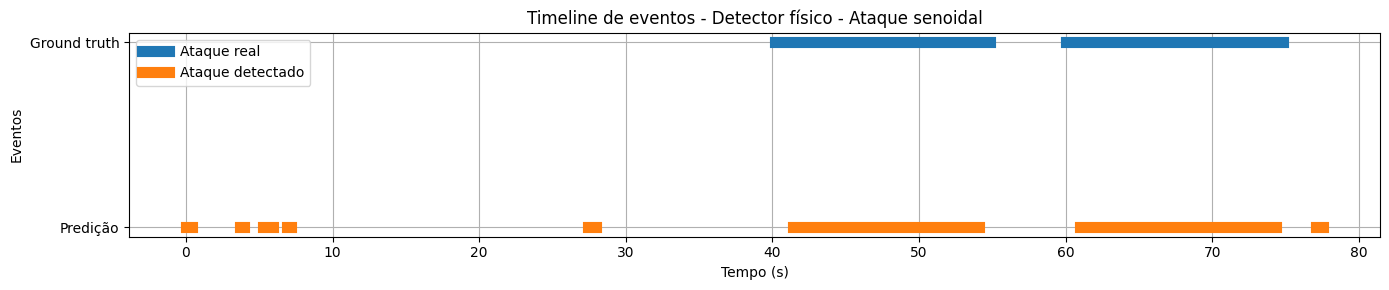

In [ ]:
plt.figure(figsize=(14, 3))

true_mask = df_eval_phys_sine["ground_truth_attack"].to_numpy()
time_vals = df_eval_phys_sine["time_s"].to_numpy()

pred_mask = df_eval_phys_sine["predicted_attack"].to_numpy()

true_line = np.where(true_mask == 1, 2, np.nan)
pred_line = np.where(pred_mask == 1, 1, np.nan)

plt.plot(time_vals, true_line, linewidth=8, label="Ataque real")
plt.plot(time_vals, pred_line, linewidth=8, label="Ataque detectado")

plt.xlabel("Tempo (s)")
plt.ylabel("Eventos")
plt.yticks([1, 2], ["Predição", "Ground truth"])
plt.title("Timeline de eventos - Detector físico - Ataque senoidal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

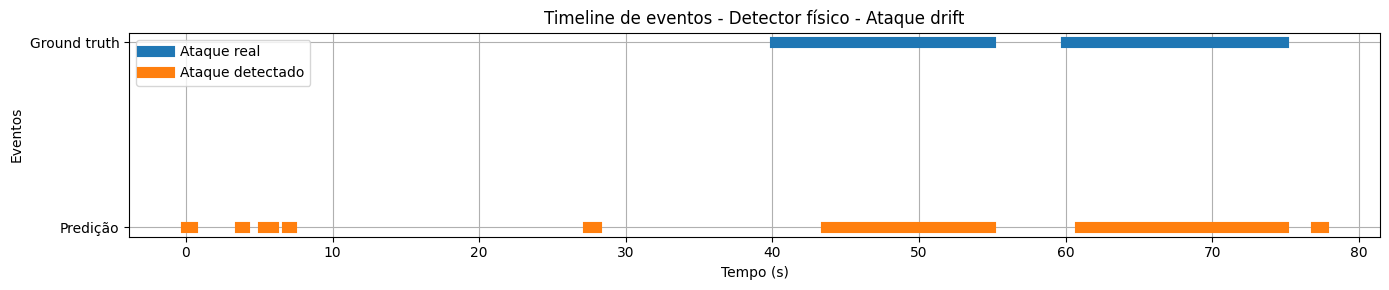

In [ ]:
plt.figure(figsize=(14, 3))

true_mask = df_eval_phys_drift["ground_truth_attack"].to_numpy()
time_vals = df_eval_phys_drift["time_s"].to_numpy()

pred_mask = df_eval_phys_drift["predicted_attack"].to_numpy()

true_line = np.where(true_mask == 1, 2, np.nan)
pred_line = np.where(pred_mask == 1, 1, np.nan)

plt.plot(time_vals, true_line, linewidth=8, label="Ataque real")
plt.plot(time_vals, pred_line, linewidth=8, label="Ataque detectado")

plt.xlabel("Tempo (s)")
plt.ylabel("Eventos")
plt.yticks([1, 2], ["Predição", "Ground truth"])
plt.title("Timeline de eventos - Detector físico - Ataque drift")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

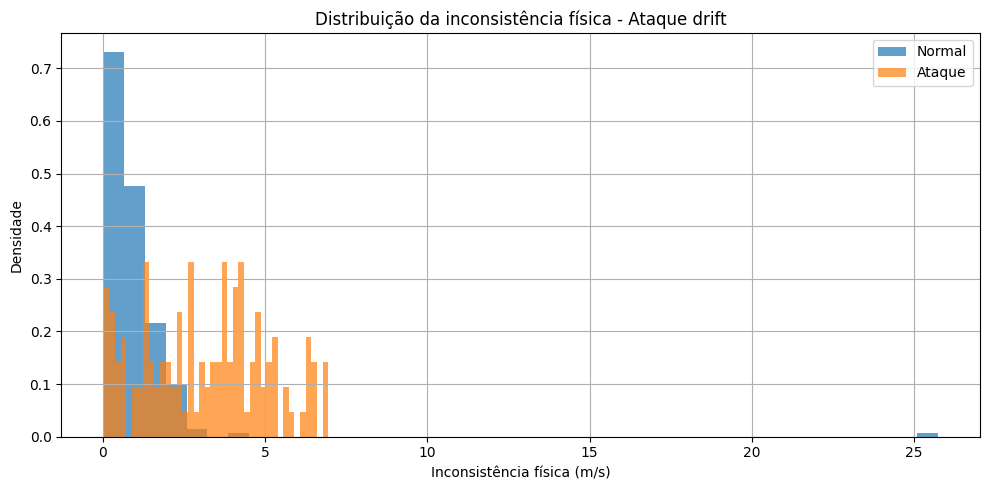

In [ ]:
plt.figure(figsize=(10, 5))

normal_vals = df_phys_drift.loc[df_phys_drift["synthetic_attack"] == 0, "phys_inconsistency"].dropna()
attack_vals = df_phys_drift.loc[df_phys_drift["synthetic_attack"] == 1, "phys_inconsistency"].dropna()

plt.hist(normal_vals, bins=40, alpha=0.7, density=True, label="Normal")
plt.hist(attack_vals, bins=40, alpha=0.7, density=True, label="Ataque")

plt.xlabel("Inconsistência física (m/s)")
plt.ylabel("Densidade")
plt.title("Distribuição da inconsistência física - Ataque drift")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def compute_f1(result_dict):
    precision = result_dict["precision"]
    recall = result_dict["recall"]

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    return f1

In [ ]:
f1_jerk_sine = compute_f1(result_jerk_sine)
f1_phys_sine = compute_f1(result_phys_sine)

f1_jerk_drift = compute_f1(result_jerk_drift)
f1_phys_drift = compute_f1(result_phys_drift)

In [ ]:
print("F1-scores")
print("----------")

print(f"Senoidal - Jerk   -> F1 = {f1_jerk_sine:.4f}")
print(f"Senoidal - Físico -> F1 = {f1_phys_sine:.4f}")

print(f"Drift    - Jerk   -> F1 = {f1_jerk_drift:.4f}")
print(f"Drift    - Físico -> F1 = {f1_phys_drift:.4f}")

F1-scores
----------
Senoidal - Jerk   -> F1 = 0.5725
Senoidal - Físico -> F1 = 0.8653
Drift    - Jerk   -> F1 = 0.4750
Drift    - Físico -> F1 = 0.8465


In [ ]:
print("Tempo mínimo:", df_original["time_s"].min())
print("Tempo máximo:", df_original["time_s"].max())

Tempo mínimo: 0.0
Tempo máximo: 79.04201030731201
